# **Day 62: Convolutional Neural Networks (CNNs)**
*Module 10 - Deep Learning Foundations*

An MLP treats an image as a flat list of numbers, ignoring that **neighbouring pixels are related** and that a pattern (an edge, a field boundary, a building) means the same thing wherever it appears. **Convolutional layers** build these two facts in: **local connectivity** and **weight sharing** (translation equivariance). CNNs are the workhorse of computer vision and of image-based remote sensing (scene classification, segmentation, object detection).

> Convolutional neural networks slide small filters over an image to detect local patterns such as edges and textures, then combine them into larger shapes. They are the standard model for images.
>
> *Example:* Early filters detect edges of fields; deeper layers combine them into the regular stripes that mean "cropland".

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F, copy, time
from torch.utils.data import DataLoader, TensorDataset
from scipy.ndimage import gaussian_filter
torch.manual_seed(62); rng = np.random.default_rng(62)

## **1. Convolution From Scratch**
A 2-D convolution slides a small **kernel** over the image and computes a weighted sum at each position (deep-learning libraries actually compute cross-correlation, without flipping the kernel):
$$(I * K)[i, j] = \sum_{u}\sum_{v} I[i+u, j+v]\,K[u, v]$$

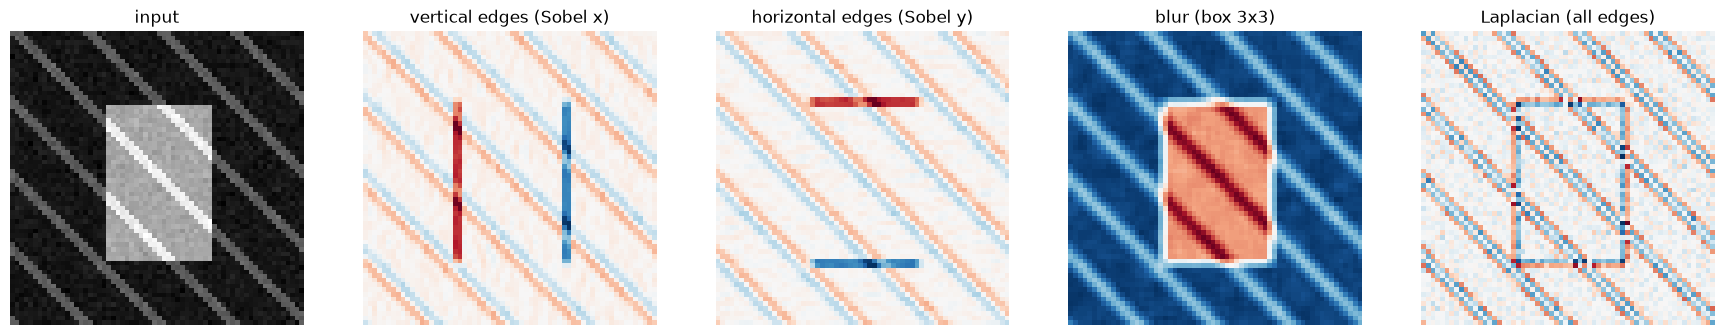

scratch == torch.nn.functional.conv2d: True


In [2]:
def conv2d_scratch(img, kernel):
    kh, kw = kernel.shape; H, W = img.shape
    out = np.zeros((H - kh + 1, W - kw + 1))
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            out[i, j] = np.sum(img[i:i + kh, j:j + kw] * kernel)
    return out

yy, xx = np.mgrid[0:64, 0:64]
img = ((xx > 20) & (xx < 44) & (yy > 15) & (yy < 50)).astype(float) + 0.5 * ((xx - yy) % 16 < 3) + rng.normal(0, 0.05, (64, 64))
kernels = {"vertical edges (Sobel x)": np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]), "horizontal edges (Sobel y)": np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]]),
           "blur (box 3x3)": np.ones((3, 3)) / 9, "Laplacian (all edges)": np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]])}
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
axes[0].imshow(img, cmap="gray"); axes[0].set_title("input")
for ax, (name, k) in zip(axes[1:], kernels.items()):
    ax.imshow(conv2d_scratch(img, k), cmap="RdBu_r"); ax.set_title(name)
for ax in axes: ax.axis("off")
plt.show()
torch_out = F.conv2d(torch.tensor(img)[None, None], torch.tensor(kernels["vertical edges (Sobel x)"], dtype=torch.float64)[None, None])[0, 0].numpy()
print("scratch == torch.nn.functional.conv2d:", np.allclose(torch_out, conv2d_scratch(img, kernels["vertical edges (Sobel x)"])))

In a CNN the kernel values are **learned**. Early layers learn edge/colour detectors like these; deeper layers combine them into textures, shapes and objects.

## **2. Padding, Stride, Channels and Output Size**
For input size $n$, kernel $k$, padding $p$, stride $s$: $\;n_{out} = \left\lfloor\frac{n + 2p - k}{s}\right\rfloor + 1$.
A conv layer maps $C_{in}$ channels to $C_{out}$ channels with $C_{out}\times C_{in}\times k\times k$ weights (+ $C_{out}$ biases): each output channel sums convolutions over **all** input channels (all spectral bands).

In [3]:
x = torch.randn(1, 4, 64, 64)                                  # one 4-band 64x64 patch
for conv in [nn.Conv2d(4, 16, 3), nn.Conv2d(4, 16, 3, padding=1), nn.Conv2d(4, 16, 3, stride=2, padding=1), nn.Conv2d(4, 16, 5, padding=2), nn.Conv2d(4, 16, 1)]:
    print(f"{str(conv):<70} -> output {tuple(conv(x).shape)} | parameters {sum(p.numel() for p in conv.parameters())}")
print("max-pool 2x2:", tuple(nn.MaxPool2d(2)(x).shape))

Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1))                       -> output (1, 16, 62, 62) | parameters 592
Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))       -> output (1, 16, 64, 64) | parameters 592
Conv2d(4, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))       -> output (1, 16, 32, 32) | parameters 592
Conv2d(4, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))       -> output (1, 16, 64, 64) | parameters 1616
Conv2d(4, 16, kernel_size=(1, 1), stride=(1, 1))                       -> output (1, 16, 64, 64) | parameters 80
max-pool 2x2: (1, 4, 32, 32)


### Receptive field
Each output unit "sees" a region of the input. Stacking 3x3 convolutions grows it: two 3x3 layers see 5x5, three see 7x7 (with fewer parameters than one 7x7 layer). Pooling and stride grow it quickly. A deep CNN's last layer sees the whole patch: global context.

## **3. Parameter Efficiency: CNN vs MLP**

In [4]:
mlp = nn.Sequential(nn.Flatten(), nn.Linear(4 * 64 * 64, 256), nn.ReLU(), nn.Linear(256, 10))
cnn = nn.Sequential(nn.Conv2d(4, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                    nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(64, 10))
print(f"MLP parameters: {sum(p.numel() for p in mlp.parameters()):,} | CNN parameters: {sum(p.numel() for p in cnn.parameters()):,}")

MLP parameters: 4,197,130 | CNN parameters: 57,258


## **4. A Synthetic EuroSAT-Like Dataset**
We generate 4-band (B, G, R, NIR) 32x32 patches of six land-cover classes. Classes differ in **spectra** and in **spatial texture**. Three vegetation classes (forest, cropland, grassland) share the **same** mean spectrum and differ only in texture (rough canopy, field stripes, smooth patches), so a model must use **spatial** information.

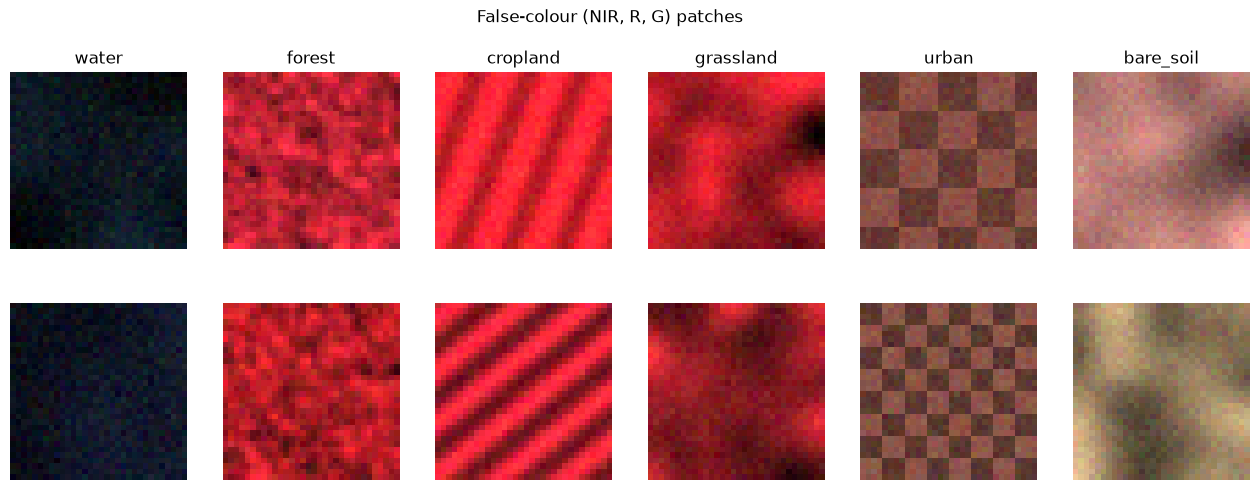

In [5]:
VEG = [0.04, 0.07, 0.05, 0.30]      # forest, cropland and grassland share ONE mean spectrum: only spatial texture separates them
SPECTRA = {"water": [0.06, 0.05, 0.03, 0.02], "forest": VEG, "cropland": VEG, "grassland": VEG,
           "urban": [0.12, 0.12, 0.13, 0.20], "bare_soil": [0.13, 0.15, 0.18, 0.24]}
CLASSES = list(SPECTRA)

def _norm(t): return (t - t.mean()) / (t.std() + 1e-9)

def make_patch(cls, size=32, r=rng):
    s = np.array(SPECTRA[cls]) * r.uniform(0.75, 1.25) * r.uniform(0.9, 1.1, 4)          # brightness + per-band variation
    yy, xx = np.mgrid[0:size, 0:size]
    if cls == "water": tex = _norm(gaussian_filter(r.normal(size=(size, size)), 6))
    elif cls == "forest": tex = _norm(gaussian_filter(r.normal(size=(size, size)), 0.8))      # fine, rough canopy
    elif cls == "cropland":
        a, per = r.uniform(0, np.pi), r.uniform(5, 10); tex = _norm(np.sin(2 * np.pi * (xx * np.cos(a) + yy * np.sin(a)) / per))   # field stripes
    elif cls == "grassland": tex = _norm(gaussian_filter(r.normal(size=(size, size)), 3))       # smooth patches
    elif cls == "urban":
        b = r.integers(4, 8); tex = _norm((((xx // b) % 2) ^ ((yy // b) % 2)).astype(float))    # block grid
    else: tex = _norm(gaussian_filter(r.normal(size=(size, size)), 4))
    return (s[:, None, None] * (1 + r.uniform(0.15, 0.3) * tex[None]) + r.normal(0, 0.012, (4, size, size))).astype(np.float32)
def make_dataset(n_per_class, size=32, seed=0):
    r = np.random.default_rng(seed)
    X = np.stack([make_patch(c, size, r) for c in CLASSES for _ in range(n_per_class)]); y = np.repeat(np.arange(len(CLASSES)), n_per_class)
    return X, y

X_tr, y_tr = make_dataset(300, seed=1); X_va, y_va = make_dataset(80, seed=2); X_te, y_te = make_dataset(150, seed=3)
mean, std = X_tr.mean((0, 2, 3), keepdims=True), X_tr.std((0, 2, 3), keepdims=True)          # per-band normalisation
norm = lambda a: (a - mean) / std
fig, axes = plt.subplots(2, 6, figsize=(16, 5.5))
for j, c in enumerate(CLASSES):
    for i in range(2):
        p = X_tr[y_tr == j][i]; axes[i, j].imshow(np.clip(p[[3, 2, 1]].transpose(1, 2, 0) / 0.4, 0, 1)); axes[i, j].axis("off")
    axes[0, j].set_title(c)
plt.suptitle("False-colour (NIR, R, G) patches"); plt.show()

## **5. Training a CNN**

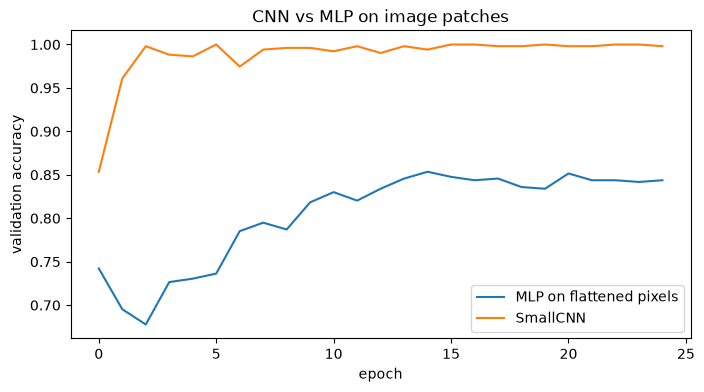

MLP on flattened pixels    test accuracy 0.862 | 1,050,374 parameters | 14s
SmallCNN                   test accuracy 0.994 | 94,758 parameters | 98s


In [6]:
def loaders(Xtr, ytr, Xva, yva, bs=64):
    mk = lambda a, b, sh: DataLoader(TensorDataset(torch.tensor(norm(a)), torch.tensor(b)), batch_size=bs, shuffle=sh)
    return mk(Xtr, ytr, True), mk(Xva, yva, False)

def train_model(model, dl_tr, dl_va, epochs=25, lr=1e-3):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4); sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    best, best_state, hist = 0, None, []
    for ep in range(epochs):
        model.train()
        for xb, yb in dl_tr:
            opt.zero_grad(); F.cross_entropy(model(xb), yb).backward(); opt.step()
        sched.step(); model.eval()
        with torch.no_grad():
            acc = np.mean([(model(xb).argmax(1) == yb).float().mean().item() for xb, yb in dl_va])
        hist.append(acc)
        if acc > best: best, best_state = acc, copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state); return hist

def evaluate(model, X, y):
    model.eval()
    with torch.no_grad(): return (model(torch.tensor(norm(X))).argmax(1).numpy() == y).mean()

class SmallCNN(nn.Module):
    def __init__(self, in_ch=4, n_classes=6):
        super().__init__()
        def block(ci, co): return nn.Sequential(nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(), nn.MaxPool2d(2))
        self.features = nn.Sequential(block(in_ch, 32), block(32, 64), block(64, 128))     # 32 -> 16 -> 8 -> 4
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(0.3), nn.Linear(128, n_classes))
    def forward(self, x):
        return self.head(self.features(x))

dl_tr, dl_va = loaders(X_tr, y_tr, X_va, y_va)
models = {"MLP on flattened pixels": nn.Sequential(nn.Flatten(), nn.Linear(4 * 32 * 32, 256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, 6)),
          "SmallCNN": SmallCNN()}
fig, ax = plt.subplots(figsize=(8, 4)); res = {}
for name, m in models.items():
    torch.manual_seed(0); t0 = time.perf_counter(); h = train_model(m, dl_tr, dl_va)
    ax.plot(h, label=name); res[name] = (evaluate(m, X_te, y_te), sum(p.numel() for p in m.parameters()), time.perf_counter() - t0)
ax.set(xlabel="epoch", ylabel="validation accuracy", title="CNN vs MLP on image patches"); ax.legend(); plt.show()
for k, (acc, npar, sec) in res.items(): print(f"{k:<26} test accuracy {acc:.3f} | {npar:,} parameters | {sec:.0f}s")

Also compare with a **spectral-only** baseline (Random Forest on per-patch band means and standard deviations). It cannot separate the three vegetation classes, which have the same spectra and the same amount of variation, only different spatial patterns.

RF on band means + stds: test accuracy 0.660


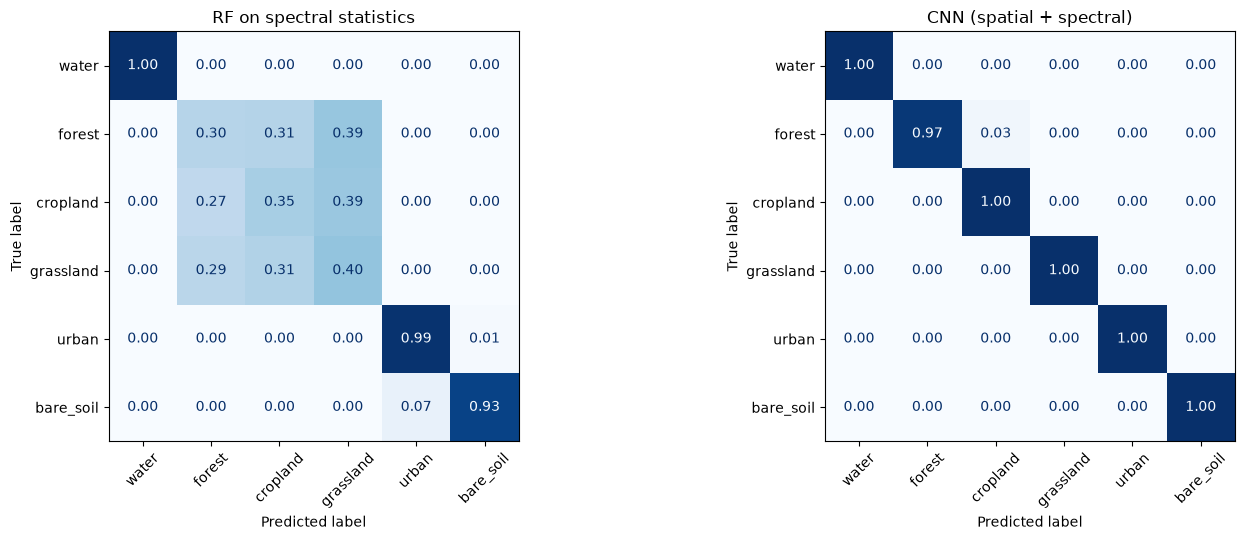

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
feat = lambda X: np.c_[X.mean((2, 3)), X.std((2, 3))]
rf = RandomForestClassifier(300, random_state=0, n_jobs=-1).fit(feat(X_tr), y_tr)
print(f"RF on band means + stds: test accuracy {rf.score(feat(X_te), y_te):.3f}")
cnn_model = models["SmallCNN"]; cnn_model.eval()
with torch.no_grad(): pred_cnn = cnn_model(torch.tensor(norm(X_te))).argmax(1).numpy()
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
ConfusionMatrixDisplay(confusion_matrix(y_te, rf.predict(feat(X_te)), normalize="true"), display_labels=CLASSES).plot(ax=axes[0], cmap="Blues", values_format=".2f", colorbar=False, xticks_rotation=45)
ConfusionMatrixDisplay(confusion_matrix(y_te, pred_cnn, normalize="true"), display_labels=CLASSES).plot(ax=axes[1], cmap="Blues", values_format=".2f", colorbar=False, xticks_rotation=45)
axes[0].set_title("RF on spectral statistics"); axes[1].set_title("CNN (spatial + spectral)"); plt.tight_layout(); plt.show()

## **6. What Did the CNN Learn?**

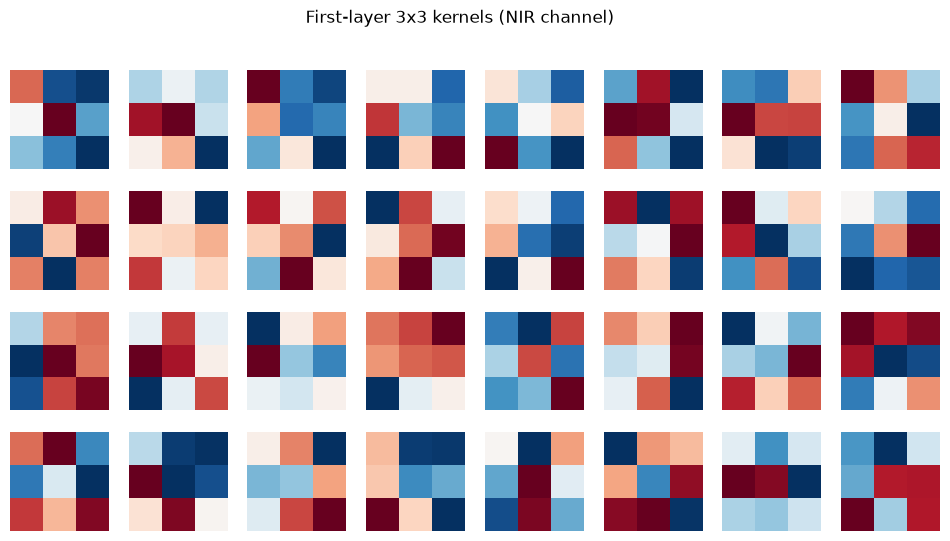

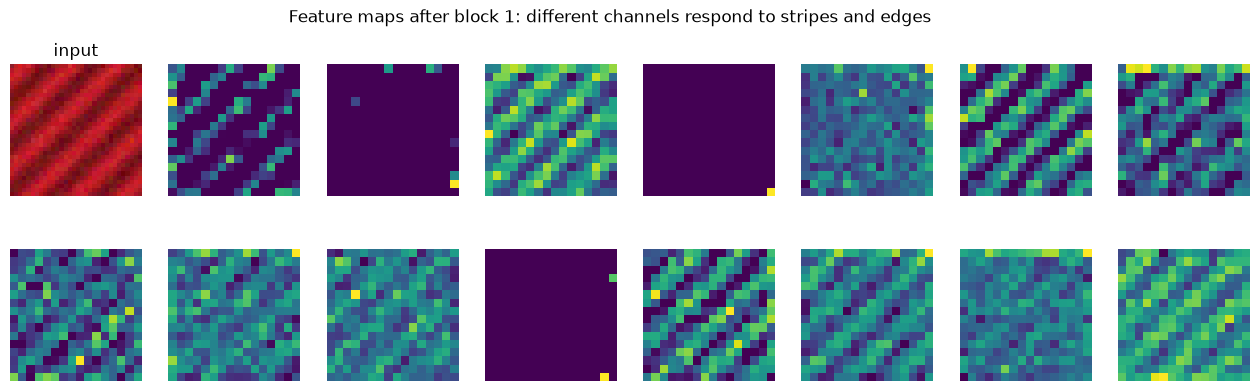

In [8]:
w1 = cnn_model.features[0][0].weight.detach().numpy()          # (32, 4, 3, 3)
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(w1[i, 3], cmap="RdBu_r"); ax.axis("off")
plt.suptitle("First-layer 3x3 kernels (NIR channel)"); plt.show()

sample = torch.tensor(norm(X_te[y_te == 2][:1]))                # a cropland patch
acts = cnn_model.features[0](sample)[0].detach().numpy()
fig, axes = plt.subplots(2, 8, figsize=(16, 4.4))
axes[0, 0].imshow(np.clip(X_te[y_te == 2][0][[3, 2, 1]].transpose(1, 2, 0) / 0.4, 0, 1)); axes[0, 0].set_title("input")
for ax, k in zip(axes.ravel()[1:], range(15)):
    ax.imshow(acts[k], cmap="viridis")
for ax in axes.ravel(): ax.axis("off")
plt.suptitle("Feature maps after block 1: different channels respond to stripes and edges"); plt.show()

# **Part 2: Going Deeper**

### Useful convolution variants
- **1x1 convolution**: mixes channels at each pixel (a per-pixel MLP over bands); used to change the number of channels cheaply.
- **Dilated (atrous) convolution**: spaces out kernel taps to grow the receptive field without pooling (used in segmentation, DeepLab).
- **Depthwise-separable convolution**: per-channel spatial conv + 1x1 mixing (MobileNet, EfficientNet): far fewer parameters.
- **Global average pooling**: one number per channel; makes the head independent of the input size.

In [9]:
for name, layer in [("standard 3x3, 64->64", nn.Conv2d(64, 64, 3, padding=1)), ("1x1, 64->64", nn.Conv2d(64, 64, 1)),
                    ("dilated 3x3 (d=2)", nn.Conv2d(64, 64, 3, padding=2, dilation=2)),
                    ("depthwise 3x3 + pointwise 1x1", nn.Sequential(nn.Conv2d(64, 64, 3, padding=1, groups=64), nn.Conv2d(64, 64, 1)))]:
    print(f"{name:<32} params {sum(p.numel() for p in layer.parameters()):>6} | output {tuple(layer(torch.randn(1, 64, 32, 32)).shape)}")

standard 3x3, 64->64             params  36928 | output (1, 64, 32, 32)
1x1, 64->64                      params   4160 | output (1, 64, 32, 32)
dilated 3x3 (d=2)                params  36928 | output (1, 64, 32, 32)
depthwise 3x3 + pointwise 1x1    params   4800 | output (1, 64, 32, 32)


### Translation equivariance and invariance
A convolution is **equivariant**: shift the input -> the feature map shifts the same way. Pooling plus global averaging makes the final prediction approximately **invariant** to shifts.

In [10]:
conv = nn.Conv2d(1, 1, 3, padding=1, bias=False)
a = torch.zeros(1, 1, 16, 16); a[0, 0, 4:7, 4:7] = 1
shifted = torch.roll(a, shifts=(5, 3), dims=(2, 3))
print("conv(shift(x)) == shift(conv(x)) (away from borders):", torch.allclose(conv(shifted)[..., 2:-2, 2:-2], torch.roll(conv(a), (5, 3), (2, 3))[..., 2:-2, 2:-2], atol=1e-6))
with torch.no_grad():
    p1 = torch.softmax(cnn_model(torch.tensor(norm(X_te[:50]))), 1); p2 = torch.softmax(cnn_model(torch.roll(torch.tensor(norm(X_te[:50])), (3, 5), (2, 3))), 1)
print("prediction agreement after shifting patches by (3, 5) pixels:", (p1.argmax(1) == p2.argmax(1)).float().mean().item())

conv(shift(x)) == shift(conv(x)) (away from borders): True
prediction agreement after shifting patches by (3, 5) pixels: 1.0


## **Practice Problems**
1. Compute the receptive field of the last conv layer in `SmallCNN` (3 blocks of 3x3 conv + 2x2 pool).
2. Train SmallCNN on only the RGB bands (drop NIR). How much accuracy is lost? Which classes suffer?
3. Replace max-pooling by stride-2 convolutions. Compare accuracy and parameters.
4. *(Advanced)* Write the convolution as a matrix multiplication (im2col): extract all 3x3 patches with `F.unfold`, multiply by the flattened kernel, and check against `F.conv2d`.

In [11]:
# Solution 1: r_l = r_(l-1) + (k - 1) * jump; jump doubles after each pool
r_f, jump = 1, 1
for _ in range(3):
    r_f += 2 * jump; r_f += 1 * jump; jump *= 2        # 3x3 conv, then 2x2 pool
print("receptive field of the final feature map:", r_f, "pixels")
# Solution 2
torch.manual_seed(0); rgb = SmallCNN(in_ch=3)
mk = lambda a, b, sh: DataLoader(TensorDataset(torch.tensor(norm(a)[:, :3]), torch.tensor(b)), batch_size=64, shuffle=sh)
train_model(rgb, mk(X_tr, y_tr, True), mk(X_va, y_va, False), epochs=20)
rgb.eval()
with torch.no_grad(): pr = rgb(torch.tensor(norm(X_te)[:, :3])).argmax(1).numpy()
print(f"RGB-only accuracy {np.mean(pr == y_te):.3f} | per-class recall:", dict(zip(CLASSES, np.round(confusion_matrix(y_te, pr, normalize='true').diagonal(), 2).tolist())))
# Solution 3
class StridedCNN(SmallCNN):
    def __init__(self):
        super().__init__()
        blk = lambda ci, co: nn.Sequential(nn.Conv2d(ci, co, 3, stride=2, padding=1), nn.BatchNorm2d(co), nn.ReLU())
        self.features = nn.Sequential(blk(4, 32), blk(32, 64), blk(64, 128))
torch.manual_seed(0); st = StridedCNN(); train_model(st, dl_tr, dl_va, epochs=20)
print(f"strided-conv CNN accuracy {evaluate(st, X_te, y_te):.3f} | params {sum(p.numel() for p in st.parameters()):,}")
# Solution 4
xin = torch.randn(1, 4, 8, 8); kern = torch.randn(16, 4, 3, 3)
cols = F.unfold(xin, 3)                                           # (1, 4*9, 36 positions)
out = (kern.view(16, -1) @ cols).view(1, 16, 6, 6)
print("im2col == conv2d:", torch.allclose(out, F.conv2d(xin, kern), atol=1e-5))

receptive field of the final feature map: 22 pixels


RGB-only accuracy 0.998 | per-class recall: {'water': 1.0, 'forest': 0.99, 'cropland': 1.0, 'grassland': 0.99, 'urban': 1.0, 'bare_soil': 1.0}


strided-conv CNN accuracy 0.993 | params 94,758
im2col == conv2d: True


## **Key References**
- LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document recognition. *Proceedings of the IEEE*, 86(11), 2278-2324.
- Krizhevsky, A., Sutskever, I., & Hinton, G. E. (2012). ImageNet classification with deep convolutional neural networks. *NeurIPS 25*.
- Dumoulin, V., & Visin, F. (2016). A guide to convolution arithmetic for deep learning. arXiv:1603.07285.
- Helber, P., Bischke, B., Dengel, A., & Borth, D. (2019). EuroSAT: A novel dataset and deep learning benchmark for land use and land cover classification. *IEEE JSTARS*, 12(7), 2217-2226.
- Zhu, X. X. et al. (2017). Deep learning in remote sensing: A comprehensive review and list of resources. *IEEE Geoscience and Remote Sensing Magazine*, 5(4), 8-36.
- Ma, L. et al. (2019). Deep learning in remote sensing applications: A meta-analysis and review. *ISPRS Journal of Photogrammetry and Remote Sensing*, 152, 166-177.